In [1]:
# 1. Import Required Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from PIL import Image

## 2. Load and Preprocess .pgm Data
Load .pgm images, preprocess, and prepare labels for training.

In [2]:
#IMPORT DATA
data_dir = r'C:\Users\VBartkiv\Downloads'
img_height = 128  
img_width = 256  

class_folders = [f for f in os.listdir(data_dir) if f.startswith('jam_bw_') and os.path.isdir(os.path.join(data_dir, f))]
class_folders.sort()  
num_classes = len(class_folders)

# Load images and labels
X, y = [], []
for idx, folder in enumerate(class_folders):
    folder_path = os.path.join(data_dir, folder)
    
    nested_path = os.path.join(folder_path, folder)
    if os.path.isdir(nested_path):
        folder_path = nested_path
    
    for fname in os.listdir(folder_path):
        if fname.endswith('.pgm'):
            img_path = os.path.join(folder_path, fname)
            img = Image.open(img_path).resize((img_width, img_height))
            img = np.array(img)
            if img.ndim == 2:
                img = np.expand_dims(img, axis=-1) 
            X.append(img)
            y.append(idx)
X = np.array(X)
y = np.array(y)
print(f"Loaded {X.shape[0]} images. Shape: {X.shape}")

Loaded 1000 images. Shape: (1000, 128, 256, 1)


## 3. Train/Test Split and Normalization
Split the data into train/test sets and normalize pixel values.

In [3]:
# Shuffle data before splitting
X, y = shuffle(X, y, random_state=42)

# Normalize and split data
X = X.astype('float32') / 255.0
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1) 

y_cat = to_categorical(y, num_classes)
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (800, 128, 256, 3), Test: (200, 128, 256, 3)


## 4. Build the CNN Model
Define and compile the convolutional neural network for classification.

In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    Dropout(0.25),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=5e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\VBartkiv\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 127, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 125, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 125, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,020,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,444,229 (85.62 MB)

 Trainable params: 22,443,269 (85.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
# Check class distribution
unique, counts = np.unique(np.argmax(y_train, axis=1), return_counts=True)
print("Training set class distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {class_folders[u]}: {c} samples")
    
unique, counts = np.unique(np.argmax(y_test, axis=1), return_counts=True)
print("\nTest set class distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {class_folders[u]}: {c} samples")

Training set class distribution:
  Class jam_bw_1000000Hz: 160 samples
  Class jam_bw_200000Hz: 160 samples
  Class jam_bw_400000Hz: 160 samples
  Class jam_bw_600000Hz: 160 samples
  Class jam_bw_800000Hz: 160 samples

Test set class distribution:
  Class jam_bw_1000000Hz: 40 samples
  Class jam_bw_200000Hz: 40 samples
  Class jam_bw_400000Hz: 40 samples
  Class jam_bw_600000Hz: 40 samples
  Class jam_bw_800000Hz: 40 samples


## 5. Train the Model
Fit the model using the training and validation data.

In [10]:
epochs = 100

# Create a proper validation set from training data
from sklearn.model_selection import train_test_split as tts
X_train_split, X_val, y_train_split, y_val = tts(
    X_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1)
)

# Early stopping with better tuned parameters
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    min_delta=0.0001,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5500 - loss: 1.5660 - val_accuracy: 0.2000 - val_loss: 1.6694
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7609 - loss: 0.6981 - val_accuracy: 0.2000 - val_loss: 1.8505
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8797 - loss: 0.3569 - val_accuracy: 0.2000 - val_loss: 2.2532
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9156 - loss: 0.2479 - val_accuracy: 0.2000 - val_loss: 2.4183
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9219 - loss: 0.2363 - val_accuracy: 0.2000 - val_loss: 2.8080
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 39s 978ms/step - accuracy: 0.9344 - loss: 0.2082 - val_accuracy: 0.2000 - val_loss: 2.7668
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9547 - loss: 0.1189 - val_accuracy: 0.2000 - val_loss: 2.4224
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9578 - loss: 0.1317 - val_accuracy: 0.2562 

## 6. Evaluate and Visualize Results
Plot training history and print classification report.

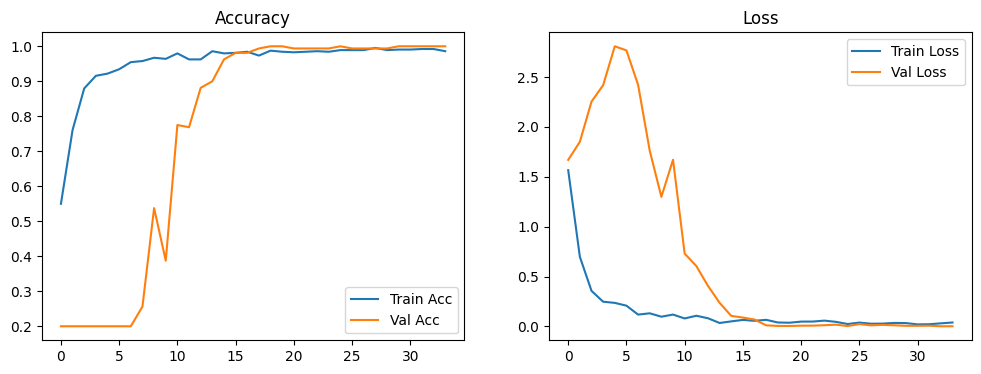

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step
Classification Report
                  precision    recall  f1-score   support

jam_bw_1000000Hz       0.98      1.00      0.99        40
 jam_bw_200000Hz       1.00      1.00      1.00        40
 jam_bw_400000Hz       1.00      1.00      1.00        40
 jam_bw_600000Hz       1.00      1.00      1.00        40
 jam_bw_800000Hz       1.00      0.97      0.99        40

        accuracy                           0.99       200
       macro avg       1.00      0.99      0.99       200
    weighted avg       1.00      0.99      0.99       200



In [11]:
# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Evaluate on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print('Classification Report')
print(classification_report(y_true, y_pred_classes, target_names=class_folders))

## 7. Predict on New .pgm Images
Function to classify a new .pgm spectrogram image.

In [15]:
def predict_pgm(img_path):
    img = Image.open(img_path).resize((img_width, img_height))
    img = np.array(img)
    if img.ndim == 2:
        img = np.expand_dims(img, axis=-1)
    img = img.astype('float32') / 255.0
    img = np.repeat(img, 3, axis=-1)
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)
    class_idx = np.argmax(pred, axis=1)[0]
    class_label = class_folders[class_idx]
    return class_label

# Example usage:
# print(predict_pgm('jam_bw_200000Hz/example.pgm'))